In [8]:
import numpy as np


# ==========================================
# Cosmological mean electron number density
# ==========================================

# Physical constants (cgs)
G       = 6.67430e-8          # gravitational constant [cm^3 g^-1 s^-2]
m_p     = 1.6726219e-24       # proton mass [g]
H0_km_s_Mpc = 67.4            # Hubble constant [km/s/Mpc]

# Convert H0 to cgs
Mpc_cm = 3.085677581e24
H0 = H0_km_s_Mpc * 1.0e5 / Mpc_cm   # [s^-1]

# Cosmological parameters
Omega_b = 0.049               # baryon density parameter
X_H = 0.76                    # hydrogen mass fraction
Y_He = 0.24                   # helium mass fraction

# Ionization fractions
# fully ionized H and HeII:
chi_H  = 1.0
chi_He = 1.0

# ------------------------------------------
# Critical density
# rho_crit = 3 H0^2 / (8 pi G)
# ------------------------------------------
rho_crit = 3 * H0**2 / (8 * np.pi * G)

# Mean baryon density today
rho_b0 = Omega_b * rho_crit

# ------------------------------------------
# Electron number density today
#
# n_e = n_H + 2 n_He  (fully ionized HeIII)
# or
# n_e = n_H + n_He    (HeII)
#
# Here:
# n_H  = X_H rho_b / m_p
# n_He = Y_He rho_b / (4 m_p)
# ------------------------------------------

n_H0 = X_H * rho_b0 / m_p
n_He0 = Y_He * rho_b0 / (4 * m_p)

# HeII
n_e0 = chi_H * n_H0 + chi_He * n_He0

print("Mean electron density today")
print(f"n_e(z=0) = {n_e0:.3e} cm^-3")


# ==========================================
# Function of redshift
# ==========================================

def mean_electron_density(z,
                          Omega_b=0.049,
                          X_H=0.76,
                          Y_He=0.24,
                          chi_H=1.0,
                          chi_He=1.0):
    """
    Cosmological mean electron density

    Parameters
    ----------
    z : float or ndarray
        Redshift

    Returns
    -------
    n_e : float or ndarray
        Electron number density [cm^-3]
    """

    rho_b = rho_b0 * (1 + z)**3

    n_H = X_H * rho_b / m_p
    n_He = Y_He * rho_b / (4 * m_p)

    n_e = chi_H * n_H + chi_He * n_He

    return n_e


# Example
for z in [0, 1, 3, 10]:
    print(f"z={z:2d} : n_e = {mean_electron_density(z):.3e} cm^-3")

Mean electron density today
n_e(z=0) = 2.050e-07 cm^-3
z= 0 : n_e = 2.050e-07 cm^-3
z= 1 : n_e = 1.640e-06 cm^-3
z= 3 : n_e = 1.312e-05 cm^-3
z=10 : n_e = 2.728e-04 cm^-3


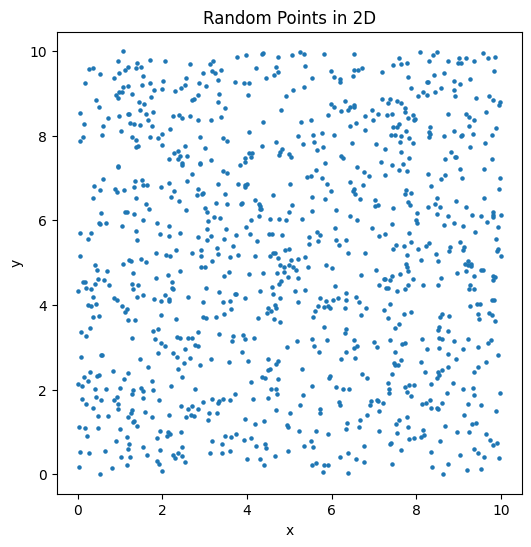

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def generate_random_points(
    n_points,
    dim=2,
    box_size=1.0,
    seed=None
):
    """
    ランダムな点群を生成する関数

    Parameters
    ----------
    n_points : int
        点の数
    dim : int
        次元数（2 or 3 を想定）
    box_size : float
        空間サイズ [0, box_size)
    seed : int or None
        乱数シード

    Returns
    -------
    points : ndarray
        shape = (n_points, dim)
    """

    rng = np.random.default_rng(seed)

    # 一様乱数で点を生成
    points = rng.uniform(
        low=0.0,
        high=box_size,
        size=(n_points, dim)
    )

    return points


# =========================
# 2次元の例
# =========================

points_2d = generate_random_points(
    n_points=1000,
    dim=2,
    box_size=10.0,
    seed=42
)

# 可視化
plt.figure(figsize=(6, 6))
plt.scatter(points_2d[:, 0], points_2d[:, 1], s=5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Random Points in 2D")
plt.axis("equal")

plt.show()

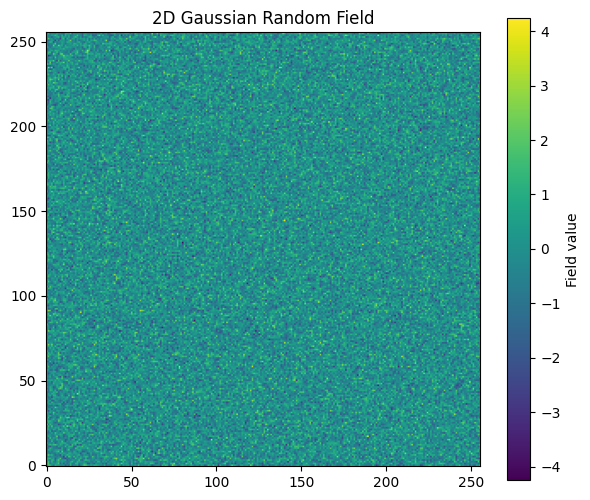

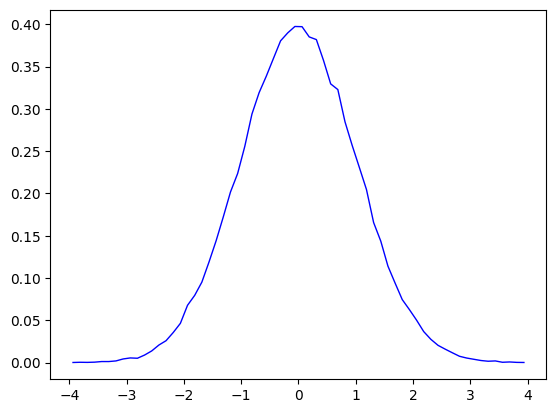

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def generate_gaussian_random_field(
    grid_size=128,
    dim=2,
    box_size=1.0,
    power_law_index=-3.0,
    seed=None,
    normalize=True
):
    """
    Gaussian Random Field を Fourier 空間で生成

    Parameters
    ----------
    grid_size : int
        各軸方向のグリッド数
    dim : int
        次元数 (2 or 3)
    box_size : float
        物理サイズ
    power_law_index : float
        P(k) ∝ k^n の指数 n
    seed : int or None
        乱数シード
    normalize : bool
        平均0・分散1へ正規化するか

    Returns
    -------
    field : ndarray
        Gaussian random field
    """

    rng = np.random.default_rng(seed)

    shape = (grid_size,) * dim

    # -----------------------------
    # k-space grid
    # -----------------------------
    k_axes = [
        np.fft.fftfreq(grid_size, d=box_size / grid_size)
        for _ in range(dim)
    ]

    k_mesh = np.meshgrid(*k_axes, indexing='ij')

    k_squared = np.zeros(shape)

    for k in k_mesh:
        k_squared += k**2

    k_mag = np.sqrt(k_squared)

    # k=0 の発散回避
    k_mag[tuple([0] * dim)] = np.inf

    # -----------------------------
    # Power spectrum
    # P(k) ∝ k^n
    # -----------------------------
    Pk = k_mag ** power_law_index

    # k=0 mode をゼロに
    Pk[tuple([0] * dim)] = 0.0

    # -----------------------------
    # Fourier mode
    # -----------------------------
    noise_real = rng.normal(size=shape)
    noise_imag = rng.normal(size=shape)

    fourier_field = (
        noise_real + 1j * noise_imag
    ) * np.sqrt(Pk)

    # -----------------------------
    # Real space field
    # -----------------------------
    field = np.fft.ifftn(fourier_field).real

    # -----------------------------
    # Normalize
    # -----------------------------
    if normalize:
        field -= np.mean(field)
        field /= np.std(field)

    return field


# =====================================
# 2D example
# =====================================

field_2d = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=1-0.96,
    seed=42
)

plt.figure(figsize=(7, 6))
plt.imshow(field_2d, origin='lower')
plt.colorbar(label='Field value')
plt.title("2D Gaussian Random Field")

plt.show()

hist, bins = np.histogram(np.ravel(field_2d), bins=64, density = True, range=(-4,4))
plt.plot((bins[:-1]+bins[1:])/2., hist, ls='-',c='b',lw=1);

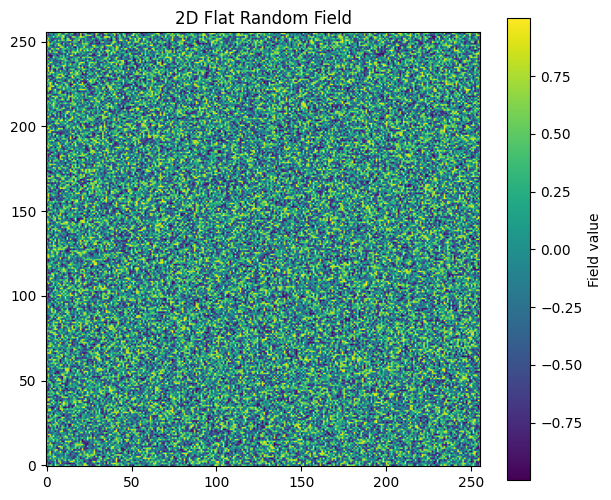

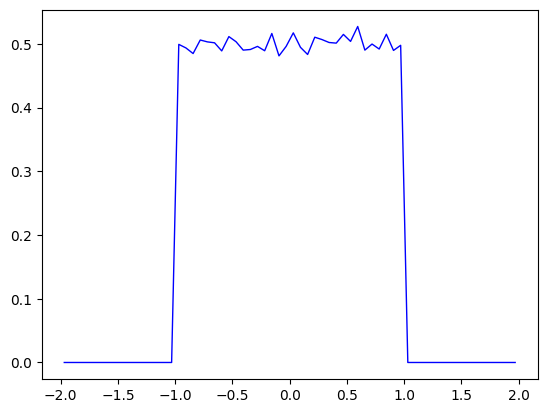

In [14]:
import numpy as np
import matplotlib.pyplot as plt


def generate_flat_random_field(
    grid_size=256,
    dim=2,
    vmin=-1.0,
    vmax=1.0,
    smooth_sigma=None,
    seed=None
):
    """
    上限・下限付き flat (uniform) random field を生成

    Parameters
    ----------
    grid_size : int
        各軸方向のグリッド数
    dim : int
        次元数 (2 or 3)
    vmin, vmax : float
        一様分布の範囲
    smooth_sigma : float or None
        smoothing scale
        None の場合は smoothing なし
    seed : int or None
        乱数シード

    Returns
    -------
    field : ndarray
        Random field
    """

    rng = np.random.default_rng(seed)

    shape = (grid_size,) * dim

    # ------------------------------------
    # Flat random field
    # ------------------------------------
    field = rng.uniform(
        low=vmin,
        high=vmax,
        size=shape
    )

    # ------------------------------------
    # Optional smoothing in Fourier space
    # ------------------------------------
    if smooth_sigma is not None:

        # Fourier transform
        fk = np.fft.fftn(field)

        # k-grid
        k_axes = [
            np.fft.fftfreq(grid_size)
            for _ in range(dim)
        ]

        k_mesh = np.meshgrid(*k_axes, indexing='ij')

        k2 = np.zeros(shape)

        for k in k_mesh:
            k2 += k**2

        # Gaussian filter
        gaussian_filter = np.exp(
            -0.5 * (2 * np.pi * smooth_sigma)**2 * k2
        )

        fk *= gaussian_filter

        field = np.fft.ifftn(fk).real

    return field


# =====================================
# 2D example
# =====================================

field_2d = generate_flat_random_field(
    grid_size=256,
    dim=2,
    vmin=-1.0,
    vmax=1.0,
    smooth_sigma=None,
    seed=42
)

plt.figure(figsize=(7, 6))

plt.imshow(field_2d, origin='lower')
plt.colorbar(label='Field value')

plt.title("2D Flat Random Field")

plt.show()

hist, bins = np.histogram(np.ravel(field_2d), bins=64, density = True, range=(-2,2))
plt.plot((bins[:-1]+bins[1:])/2., hist, ls='-',c='b',lw=1);

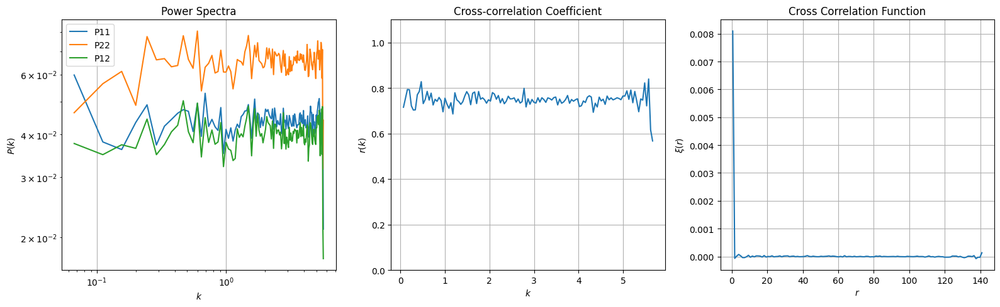

In [21]:
import numpy as np
import matplotlib.pyplot as plt


def compute_cross_statistics(
    field1,
    field2,
    box_size=1.0,
    nbins=None
):
    """
    Compute:
        - Auto power spectra
        - Cross power spectrum
        - Cross-correlation coefficient
        - Correlation function

    Parameters
    ----------
    field1, field2 : ndarray
        Input fields (2D or 3D)

    box_size : float
        Physical box size

    nbins : int or None
        Number of radial bins

    Returns
    -------
    results : dict
    """

    assert field1.shape == field2.shape

    shape = field1.shape
    dim = field1.ndim
    N = shape[0]

    if nbins is None:
        nbins = N // 2

    # =====================================================
    # Overdensity fields
    # =====================================================

    d1 = field1 / np.mean(field1) - 1.0
    d2 = field2 / np.mean(field2) - 1.0

    # =====================================================
    # FFT
    # =====================================================

    fk1 = np.fft.fftn(d1)
    fk2 = np.fft.fftn(d2)

    # =====================================================
    # Power spectra
    # =====================================================

    P11 = (fk1 * np.conjugate(fk1)).real
    P22 = (fk2 * np.conjugate(fk2)).real
    P12 = (fk1 * np.conjugate(fk2)).real

    norm = np.prod(shape)

    P11 /= norm
    P22 /= norm
    P12 /= norm

    # =====================================================
    # k-grid
    # =====================================================

    k_axes = [
        2 * np.pi * np.fft.fftfreq(
            N,
            d=box_size / N
        )
        for _ in range(dim)
    ]

    k_mesh = np.meshgrid(*k_axes, indexing='ij')

    k2 = np.zeros(shape)

    for k in k_mesh:
        k2 += k**2

    k_mag = np.sqrt(k2)

    # =====================================================
    # Bin power spectra
    # =====================================================

    k_flat = k_mag.flatten()

    P11_flat = P11.flatten()
    P22_flat = P22.flatten()
    P12_flat = P12.flatten()

    k_max = np.max(k_mag)

    k_bins = np.linspace(0, k_max, nbins + 1)

    k_centers = 0.5 * (
        k_bins[:-1] + k_bins[1:]
    )

    P11_bin = np.zeros(nbins)
    P22_bin = np.zeros(nbins)
    P12_bin = np.zeros(nbins)

    for i in range(nbins):

        mask = (
            (k_flat >= k_bins[i]) &
            (k_flat < k_bins[i+1])
        )

        if np.any(mask):

            P11_bin[i] = np.mean(P11_flat[mask])
            P22_bin[i] = np.mean(P22_flat[mask])
            P12_bin[i] = np.mean(P12_flat[mask])

    # =====================================================
    # Cross-correlation coefficient
    # =====================================================

    r_k = P12_bin / np.sqrt(P11_bin * P22_bin)

    # =====================================================
    # Correlation function
    # =====================================================

    xi = np.fft.ifftn(
        fk1 * np.conjugate(fk2)
    ).real

    xi /= norm

    xi = np.fft.fftshift(xi)

    # =====================================================
    # r-grid
    # =====================================================

    dx = box_size / N

    x_axes = [
        (np.arange(N) - N//2) * dx
        for _ in range(dim)
    ]

    x_mesh = np.meshgrid(*x_axes, indexing='ij')

    r2 = np.zeros(shape)

    for x in x_mesh:
        r2 += x**2

    r_mag = np.sqrt(r2)

    # =====================================================
    # Bin xi(r)
    # =====================================================

    r_flat = r_mag.flatten()
    xi_flat = xi.flatten()

    r_max = np.max(r_mag)

    r_bins = np.linspace(0, r_max, nbins + 1)

    r_centers = 0.5 * (
        r_bins[:-1] + r_bins[1:]
    )

    xi_bin = np.zeros(nbins)

    for i in range(nbins):

        mask = (
            (r_flat >= r_bins[i]) &
            (r_flat < r_bins[i+1])
        )

        if np.any(mask):
            xi_bin[i] = np.mean(xi_flat[mask])

    return {
        "k": k_centers,
        "P11": P11_bin,
        "P22": P22_bin,
        "P12": P12_bin,
        "r_k": r_k,
        "r": r_centers,
        "xi": xi_bin
    }


# =========================================================
# Example
# =========================================================

N = 256
box_size = 200.0

rng = np.random.default_rng(42)

# Correlated fields
signal = rng.normal(size=(N, N))

noise1 = rng.normal(size=(N, N))
noise2 = rng.normal(size=(N, N))

field1 = signal + 0.3 * noise1
field2 = signal + 0.8 * noise2

# Shift positive
field1 += 5.0
field2 += 5.0

# =========================================================
# Compute
# =========================================================

res = compute_cross_statistics(
    field1,
    field2,
    box_size=box_size
)

# =========================================================
# Plot
# =========================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

# ---------------------------------------------------------
# Power spectra
# ---------------------------------------------------------

axes[0].plot(res["k"][1:], res["P11"][1:], label="P11")
axes[0].plot(res["k"][1:], res["P22"][1:], label="P22")
axes[0].plot(res["k"][1:], res["P12"][1:], label="P12")

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel(r"$P(k)$")

axes[0].set_title("Power Spectra")

axes[0].legend()
axes[0].grid()

# ---------------------------------------------------------
# Cross-correlation coefficient
# ---------------------------------------------------------

axes[1].plot(res["k"][1:], res["r_k"][1:])

axes[1].set_xlabel(r"$k$")
axes[1].set_ylabel(r"$r(k)$")

axes[1].set_title("Cross-correlation Coefficient")

axes[1].set_ylim(0, 1.1)

axes[1].grid()

# ---------------------------------------------------------
# Correlation function
# ---------------------------------------------------------

axes[2].plot(res["r"], res["xi"])

axes[2].set_xlabel(r"$r$")
axes[2].set_ylabel(r"$\xi(r)$")

axes[2].set_title("Cross Correlation Function")

axes[2].grid()

plt.tight_layout()
plt.show()

# no correlation

Now, matter density and magnetic field are not correlated


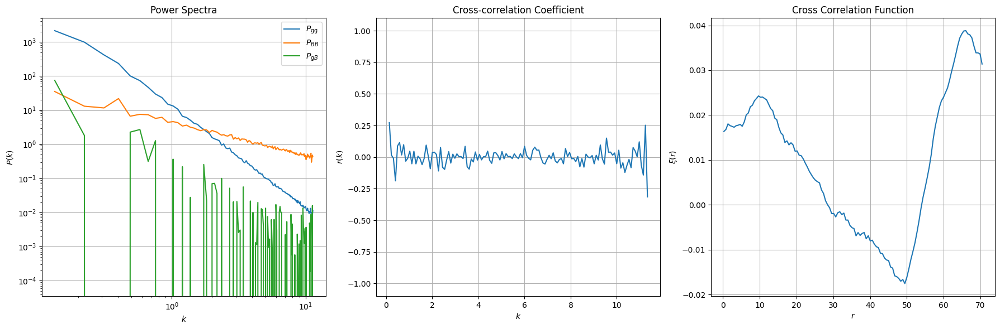

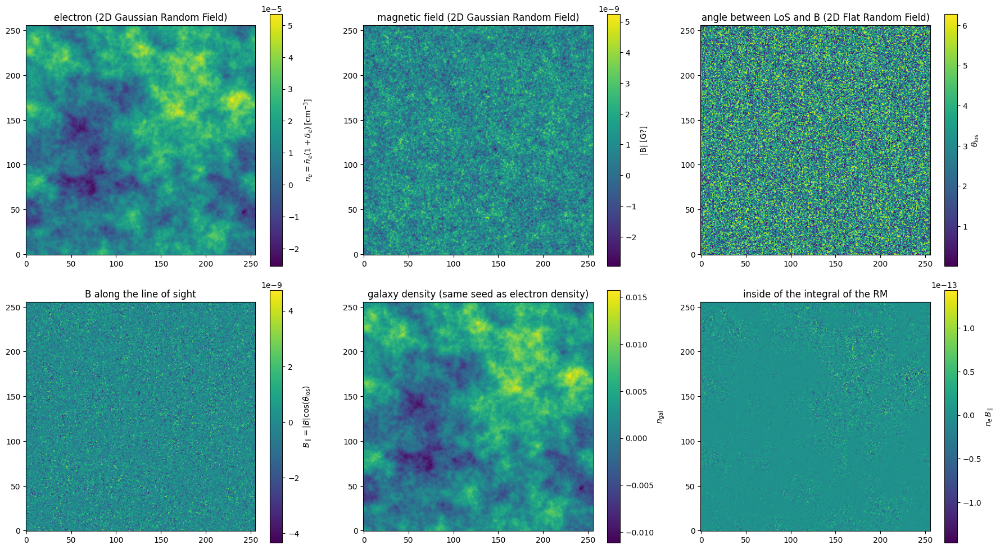

In [77]:
print("Now, matter density and magnetic field are not correlated")

delta_m = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-3,
    seed=42
)
bias_em = 0.9
electron_density = mean_electron_density(z=3)*(1+delta_m*bias_em)
bias_gm = 2
galaxy_density = 1e-3*bias_gm*(1+delta_m*bias_gm)

delta_B = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-1,
    seed=53
)
bias_Bm = 0.5
magnetic_field = 1e-9*(1+delta_B)

los_angle = generate_flat_random_field(
    grid_size=256,
    dim=2,
    vmin=0.,
    vmax=2.*np.pi,
    smooth_sigma=None,
    seed=33
)
B_para = magnetic_field * np.cos(los_angle)
B_perp = magnetic_field * np.sin(los_angle)

#---------------- compute statistics ---------------
res = compute_cross_statistics(
    galaxy_density,
    magnetic_field,
    box_size=100.
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# ---------------------------------------------------------
# Power spectra
# ---------------------------------------------------------

axes[0].plot(res["k"][1:], res["P11"][1:], label=r"$P_\mathrm{gg}$")
axes[0].plot(res["k"][1:], res["P22"][1:], label=r"$P_{BB}$")
axes[0].plot(res["k"][1:], res["P12"][1:], label=r"$P_{\mathrm{g}B}$")

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel(r"$P(k)$")

axes[0].set_title("Power Spectra")

axes[0].legend()
axes[0].grid()

# ---------------------------------------------------------
# Cross-correlation coefficient
# ---------------------------------------------------------

axes[1].plot(res["k"][1:], res["r_k"][1:])

axes[1].set_xlabel(r"$k$")
axes[1].set_ylabel(r"$r(k)$")

axes[1].set_title("Cross-correlation Coefficient")

axes[1].set_ylim(-1.1, 1.1)

axes[1].grid()

# ---------------------------------------------------------
# Correlation function
# ---------------------------------------------------------

axes[2].plot(res["r"], res["xi"])

axes[2].set_xlabel(r"$r$")
axes[2].set_ylabel(r"$\xi(r)$")

axes[2].set_title("Cross Correlation Function")

axes[2].grid()

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

# =====================================================
# 1
# =====================================================

im0 = axes[0, 0].imshow(
    electron_density,
    origin='lower'
)

axes[0, 0].set_title(
    r"electron (2D Gaussian Random Field)"
)

cbar0 = plt.colorbar(
    im0,
    ax=axes[0, 0]
)

cbar0.set_label(
    r'$n_e=\bar{n}_e(1+\delta_e)\,[\mathrm{cm}^{-3}]$'
)

# =====================================================
# 2
# =====================================================

im1 = axes[0, 1].imshow(
    magnetic_field,
    origin='lower'
)

axes[0, 1].set_title(
    "magnetic field (2D Gaussian Random Field)"
)

cbar1 = plt.colorbar(
    im1,
    ax=axes[0, 1]
)

cbar1.set_label('|B| [G?]')

# =====================================================
# 3
# =====================================================

im2 = axes[0, 2].imshow(
    los_angle,
    origin='lower'
)

axes[0, 2].set_title(
    "angle between LoS and B (2D Flat Random Field)"
)

cbar2 = plt.colorbar(
    im2,
    ax=axes[0, 2]
)

cbar2.set_label(
    r'$\theta_\mathrm{los}$'
)

# =====================================================
# 4
# =====================================================

im3 = axes[1, 0].imshow(
    B_para,
    origin='lower'
)

axes[1, 0].set_title(
    "B along the line of sight"
)

cbar3 = plt.colorbar(
    im3,
    ax=axes[1, 0]
)

cbar3.set_label(
    r'$B_{\parallel}=|B|\cos(\theta_\mathrm{los})$'
)

# =====================================================
# 5
# =====================================================

im4 = axes[1, 1].imshow(
    galaxy_density,
    origin='lower'
)

axes[1, 1].set_title(
    "galaxy density (same seed as electron density)"
)

cbar4 = plt.colorbar(
    im4,
    ax=axes[1, 1]
)

cbar4.set_label(
    r'$n_\mathrm{gal}$'
)

# =====================================================
# 6
# =====================================================

im5 = axes[1, 2].imshow(
    B_para * electron_density,
    origin='lower'
)

axes[1, 2].set_title(
    "inside of the integral of the RM"
)

cbar5 = plt.colorbar(
    im5,
    ax=axes[1, 2]
)

cbar5.set_label(
    r'$n_e\,B_{\parallel}$'
)

# =====================================================
# Layout
# =====================================================

plt.tight_layout()

plt.show()

Now, matter density and magnetic field are correlated through dark matter


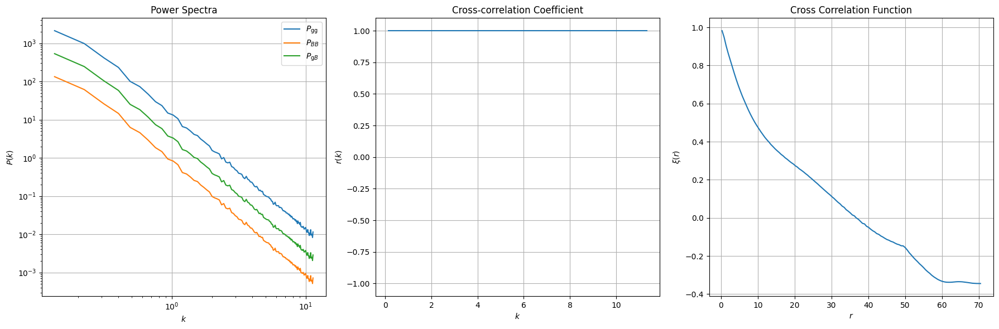

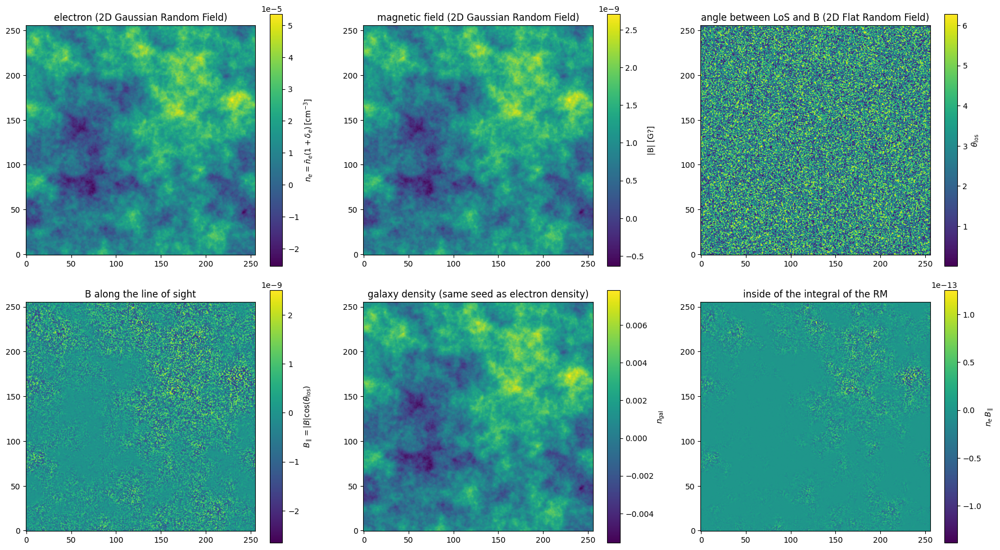

In [78]:
print("Now, matter density and magnetic field are correlated through dark matter")

delta_m = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-3,
    seed=42
)
bias_em = 0.9
electron_density = mean_electron_density(z=3)*(1+delta_m*bias_em)
bias_gm = 2
galaxy_density = 1e-3*(1+delta_m*bias_gm)

delta_B = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-1,
    seed=53
)
bias_Bm = 0.5
magnetic_field = 1e-9*(1+delta_m*bias_Bm)

los_angle = generate_flat_random_field(
    grid_size=256,
    dim=2,
    vmin=0.,
    vmax=2.*np.pi,
    smooth_sigma=None,
    seed=33
)
B_para = magnetic_field * np.cos(los_angle)
B_perp = magnetic_field * np.sin(los_angle)

#---------------- compute statistics ---------------
res = compute_cross_statistics(
    galaxy_density,
    magnetic_field,
    box_size=100.
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# ---------------------------------------------------------
# Power spectra
# ---------------------------------------------------------

axes[0].plot(res["k"][1:], res["P11"][1:], label=r"$P_\mathrm{gg}$")
axes[0].plot(res["k"][1:], res["P22"][1:], label=r"$P_{BB}$")
axes[0].plot(res["k"][1:], res["P12"][1:], label=r"$P_{\mathrm{g}B}$")

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel(r"$P(k)$")

axes[0].set_title("Power Spectra")

axes[0].legend()
axes[0].grid()

# ---------------------------------------------------------
# Cross-correlation coefficient
# ---------------------------------------------------------

axes[1].plot(res["k"][1:], res["r_k"][1:])

axes[1].set_xlabel(r"$k$")
axes[1].set_ylabel(r"$r(k)$")

axes[1].set_title("Cross-correlation Coefficient")

axes[1].set_ylim(-1.1, 1.1)

axes[1].grid()

# ---------------------------------------------------------
# Correlation function
# ---------------------------------------------------------

axes[2].plot(res["r"], res["xi"])

axes[2].set_xlabel(r"$r$")
axes[2].set_ylabel(r"$\xi(r)$")

axes[2].set_title("Cross Correlation Function")

axes[2].grid()

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

# =====================================================
# 1
# =====================================================

im0 = axes[0, 0].imshow(
    electron_density,
    origin='lower'
)

axes[0, 0].set_title(
    r"electron (2D Gaussian Random Field)"
)

cbar0 = plt.colorbar(
    im0,
    ax=axes[0, 0]
)

cbar0.set_label(
    r'$n_e=\bar{n}_e(1+\delta_e)\,[\mathrm{cm}^{-3}]$'
)

# =====================================================
# 2
# =====================================================

im1 = axes[0, 1].imshow(
    magnetic_field,
    origin='lower'
)

axes[0, 1].set_title(
    "magnetic field (2D Gaussian Random Field)"
)

cbar1 = plt.colorbar(
    im1,
    ax=axes[0, 1]
)

cbar1.set_label('|B| [G?]')

# =====================================================
# 3
# =====================================================

im2 = axes[0, 2].imshow(
    los_angle,
    origin='lower'
)

axes[0, 2].set_title(
    "angle between LoS and B (2D Flat Random Field)"
)

cbar2 = plt.colorbar(
    im2,
    ax=axes[0, 2]
)

cbar2.set_label(
    r'$\theta_\mathrm{los}$'
)

# =====================================================
# 4
# =====================================================

im3 = axes[1, 0].imshow(
    B_para,
    origin='lower'
)

axes[1, 0].set_title(
    "B along the line of sight"
)

cbar3 = plt.colorbar(
    im3,
    ax=axes[1, 0]
)

cbar3.set_label(
    r'$B_{\parallel}=|B|\cos(\theta_\mathrm{los})$'
)

# =====================================================
# 5
# =====================================================

im4 = axes[1, 1].imshow(
    galaxy_density,
    origin='lower'
)

axes[1, 1].set_title(
    "galaxy density (same seed as electron density)"
)

cbar4 = plt.colorbar(
    im4,
    ax=axes[1, 1]
)

cbar4.set_label(
    r'$n_\mathrm{gal}$'
)

# =====================================================
# 6
# =====================================================

im5 = axes[1, 2].imshow(
    B_para * electron_density,
    origin='lower'
)

axes[1, 2].set_title(
    "inside of the integral of the RM"
)

cbar5 = plt.colorbar(
    im5,
    ax=axes[1, 2]
)

cbar5.set_label(
    r'$n_e\,B_{\parallel}$'
)

# =====================================================
# Layout
# =====================================================

plt.tight_layout()

plt.show()

Now, matter density and magnetic field are correlated, but parallel B are randomly aligned


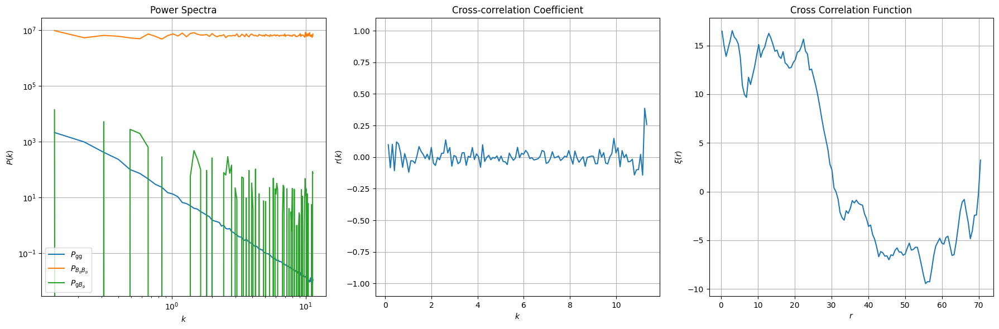

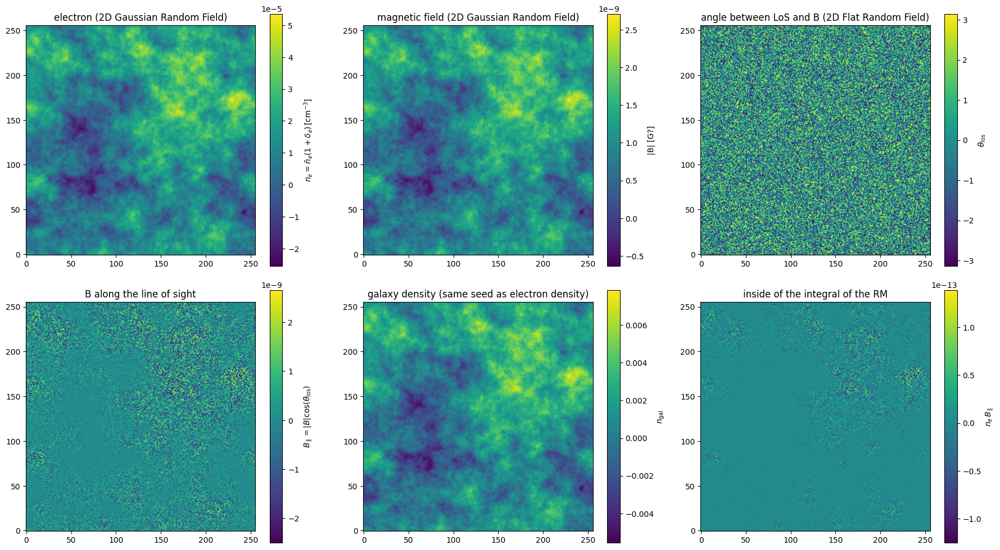

In [79]:
print("Now, matter density and magnetic field are correlated, but parallel B are randomly aligned")

delta_m = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-3,
    seed=42
)
bias_em = 0.9
electron_density = mean_electron_density(z=3)*(1+delta_m*bias_em)
bias_gm = 2
galaxy_density = 1e-3*(1+delta_m*bias_gm)

delta_B = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-1,
    seed=53
)
bias_Bm = 0.5
magnetic_field = 1e-9*(1.+delta_m*bias_Bm)

los_angle = generate_flat_random_field(
    grid_size=256,
    dim=2,
    vmin=-np.pi,
    vmax=np.pi,
    smooth_sigma=None,
    seed=33
)
B_para = magnetic_field * np.cos(los_angle)
B_perp = magnetic_field * np.sin(los_angle)

#---------------- compute statistics ---------------
res = compute_cross_statistics(
    galaxy_density,
    B_para,
    box_size=100.
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# ---------------------------------------------------------
# Power spectra
# ---------------------------------------------------------

axes[0].plot(res["k"][1:], res["P11"][1:], label=r"$P_\mathrm{gg}$")
axes[0].plot(res["k"][1:], res["P22"][1:], label=r"$P_{B_\mathrm{p}B_\mathrm{p}}$")
axes[0].plot(res["k"][1:], res["P12"][1:], label=r"$P_{\mathrm{g}B_\mathrm{p}}$")

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel(r"$P(k)$")

axes[0].set_title("Power Spectra")

axes[0].legend()
axes[0].grid()

# ---------------------------------------------------------
# Cross-correlation coefficient
# ---------------------------------------------------------

axes[1].plot(res["k"][1:], res["r_k"][1:])

axes[1].set_xlabel(r"$k$")
axes[1].set_ylabel(r"$r(k)$")

axes[1].set_title("Cross-correlation Coefficient")

axes[1].set_ylim(-1.1, 1.1)

axes[1].grid()

# ---------------------------------------------------------
# Correlation function
# ---------------------------------------------------------

axes[2].plot(res["r"], res["xi"])

axes[2].set_xlabel(r"$r$")
axes[2].set_ylabel(r"$\xi(r)$")

axes[2].set_title("Cross Correlation Function")

axes[2].grid()

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

# =====================================================
# 1
# =====================================================

im0 = axes[0, 0].imshow(
    electron_density,
    origin='lower'
)

axes[0, 0].set_title(
    r"electron (2D Gaussian Random Field)"
)

cbar0 = plt.colorbar(
    im0,
    ax=axes[0, 0]
)

cbar0.set_label(
    r'$n_e=\bar{n}_e(1+\delta_e)\,[\mathrm{cm}^{-3}]$'
)

# =====================================================
# 2
# =====================================================

im1 = axes[0, 1].imshow(
    magnetic_field,
    origin='lower'
)

axes[0, 1].set_title(
    "magnetic field (2D Gaussian Random Field)"
)

cbar1 = plt.colorbar(
    im1,
    ax=axes[0, 1]
)

cbar1.set_label('|B| [G?]')

# =====================================================
# 3
# =====================================================

im2 = axes[0, 2].imshow(
    los_angle,
    origin='lower'
)

axes[0, 2].set_title(
    "angle between LoS and B (2D Flat Random Field)"
)

cbar2 = plt.colorbar(
    im2,
    ax=axes[0, 2]
)

cbar2.set_label(
    r'$\theta_\mathrm{los}$'
)

# =====================================================
# 4
# =====================================================

im3 = axes[1, 0].imshow(
    B_para,
    origin='lower'
)

axes[1, 0].set_title(
    "B along the line of sight"
)

cbar3 = plt.colorbar(
    im3,
    ax=axes[1, 0]
)

cbar3.set_label(
    r'$B_{\parallel}=|B|\cos(\theta_\mathrm{los})$'
)

# =====================================================
# 5
# =====================================================

im4 = axes[1, 1].imshow(
    galaxy_density,
    origin='lower'
)

axes[1, 1].set_title(
    "galaxy density (same seed as electron density)"
)

cbar4 = plt.colorbar(
    im4,
    ax=axes[1, 1]
)

cbar4.set_label(
    r'$n_\mathrm{gal}$'
)

# =====================================================
# 6
# =====================================================

im5 = axes[1, 2].imshow(
    B_para * electron_density,
    origin='lower'
)

axes[1, 2].set_title(
    "inside of the integral of the RM"
)

cbar5 = plt.colorbar(
    im5,
    ax=axes[1, 2]
)

cbar5.set_label(
    r'$n_e\,B_{\parallel}$'
)

# =====================================================
# Layout
# =====================================================

plt.tight_layout()

plt.show()

Now, matter density and magnetic field are correlated, but parallel B are randomly aligned


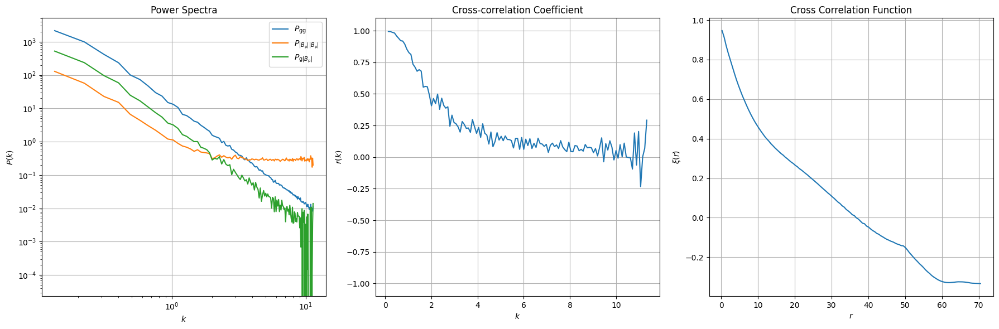

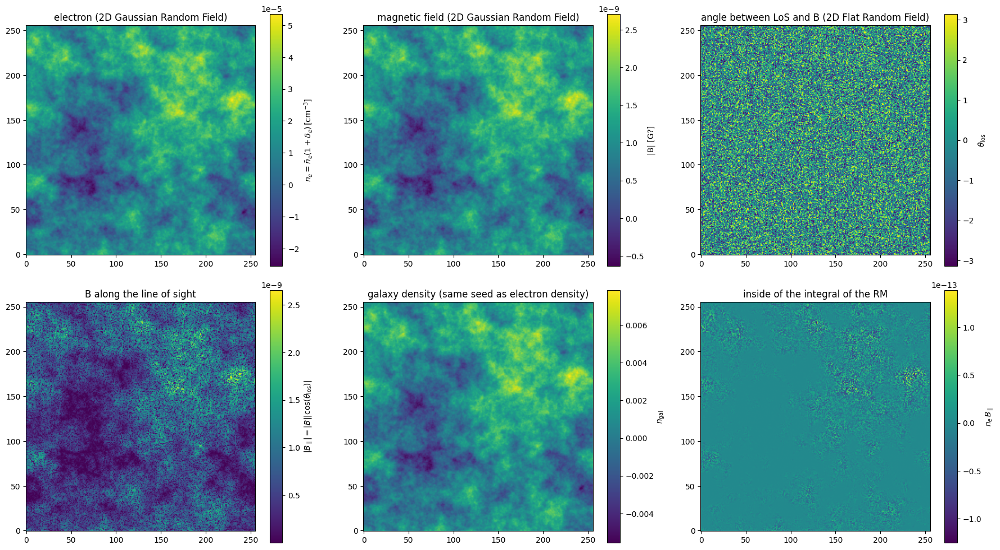

In [81]:
print("Now, matter density and magnetic field are correlated, but parallel B are randomly aligned")

delta_m = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-3,
    seed=42
)
bias_em = 0.9
electron_density = mean_electron_density(z=3)*(1+delta_m*bias_em)
bias_gm = 2
galaxy_density = 1e-3*(1+delta_m*bias_gm)

delta_B = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-1,
    seed=53
)
bias_Bm = 0.5
magnetic_field = 1e-9*(1.+delta_m*bias_Bm)

los_angle = generate_flat_random_field(
    grid_size=256,
    dim=2,
    vmin=-np.pi,
    vmax=np.pi,
    smooth_sigma=None,
    seed=33
)
B_para = magnetic_field * np.cos(los_angle)
B_perp = magnetic_field * np.sin(los_angle)

#---------------- compute statistics ---------------
res = compute_cross_statistics(
    galaxy_density,
    np.abs(B_para),
    box_size=100.
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# ---------------------------------------------------------
# Power spectra
# ---------------------------------------------------------

axes[0].plot(res["k"][1:], res["P11"][1:], label=r"$P_\mathrm{gg}$")
axes[0].plot(res["k"][1:], res["P22"][1:], label=r"$P_{|B_\mathrm{p}||B_\mathrm{p}|}$")
axes[0].plot(res["k"][1:], res["P12"][1:], label=r"$P_{\mathrm{g}|B_\mathrm{p}|}$")

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel(r"$P(k)$")

axes[0].set_title("Power Spectra")

axes[0].legend()
axes[0].grid()

# ---------------------------------------------------------
# Cross-correlation coefficient
# ---------------------------------------------------------

axes[1].plot(res["k"][1:], res["r_k"][1:])

axes[1].set_xlabel(r"$k$")
axes[1].set_ylabel(r"$r(k)$")

axes[1].set_title("Cross-correlation Coefficient")

axes[1].set_ylim(-1.1, 1.1)

axes[1].grid()

# ---------------------------------------------------------
# Correlation function
# ---------------------------------------------------------

axes[2].plot(res["r"], res["xi"])

axes[2].set_xlabel(r"$r$")
axes[2].set_ylabel(r"$\xi(r)$")

axes[2].set_title("Cross Correlation Function")

axes[2].grid()

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

# =====================================================
# 1
# =====================================================

im0 = axes[0, 0].imshow(
    electron_density,
    origin='lower'
)

axes[0, 0].set_title(
    r"electron (2D Gaussian Random Field)"
)

cbar0 = plt.colorbar(
    im0,
    ax=axes[0, 0]
)

cbar0.set_label(
    r'$n_e=\bar{n}_e(1+\delta_e)\,[\mathrm{cm}^{-3}]$'
)

# =====================================================
# 2
# =====================================================

im1 = axes[0, 1].imshow(
    magnetic_field,
    origin='lower'
)

axes[0, 1].set_title(
    "magnetic field (2D Gaussian Random Field)"
)

cbar1 = plt.colorbar(
    im1,
    ax=axes[0, 1]
)

cbar1.set_label('|B| [G?]')

# =====================================================
# 3
# =====================================================

im2 = axes[0, 2].imshow(
    los_angle,
    origin='lower'
)

axes[0, 2].set_title(
    "angle between LoS and B (2D Flat Random Field)"
)

cbar2 = plt.colorbar(
    im2,
    ax=axes[0, 2]
)

cbar2.set_label(
    r'$\theta_\mathrm{los}$'
)

# =====================================================
# 4
# =====================================================

im3 = axes[1, 0].imshow(
    np.abs(B_para),
    origin='lower'
)

axes[1, 0].set_title(
    "B along the line of sight"
)

cbar3 = plt.colorbar(
    im3,
    ax=axes[1, 0]
)

cbar3.set_label(
    r'$|B_{\parallel}|=|B||\cos(\theta_\mathrm{los})|$'
)

# =====================================================
# 5
# =====================================================

im4 = axes[1, 1].imshow(
    galaxy_density,
    origin='lower'
)

axes[1, 1].set_title(
    "galaxy density (same seed as electron density)"
)

cbar4 = plt.colorbar(
    im4,
    ax=axes[1, 1]
)

cbar4.set_label(
    r'$n_\mathrm{gal}$'
)

# =====================================================
# 6
# =====================================================

im5 = axes[1, 2].imshow(
    B_para * electron_density,
    origin='lower'
)

axes[1, 2].set_title(
    "inside of the integral of the RM"
)

cbar5 = plt.colorbar(
    im5,
    ax=axes[1, 2]
)

cbar5.set_label(
    r'$n_e\,B_{\parallel}$'
)

# =====================================================
# Layout
# =====================================================

plt.tight_layout()

plt.show()

correlation between cos(theta) and B_parallel


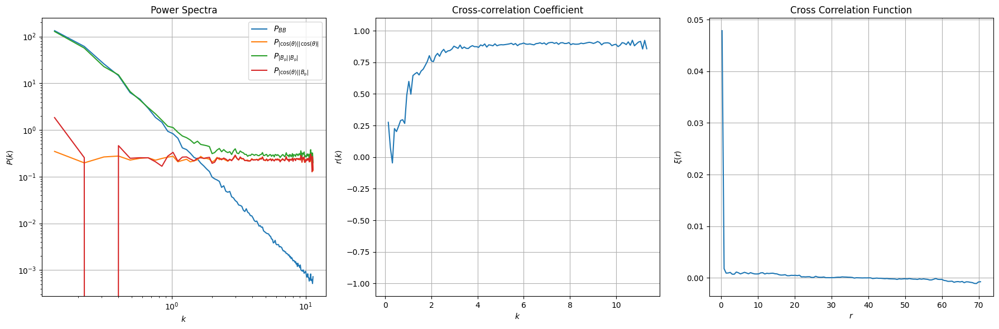

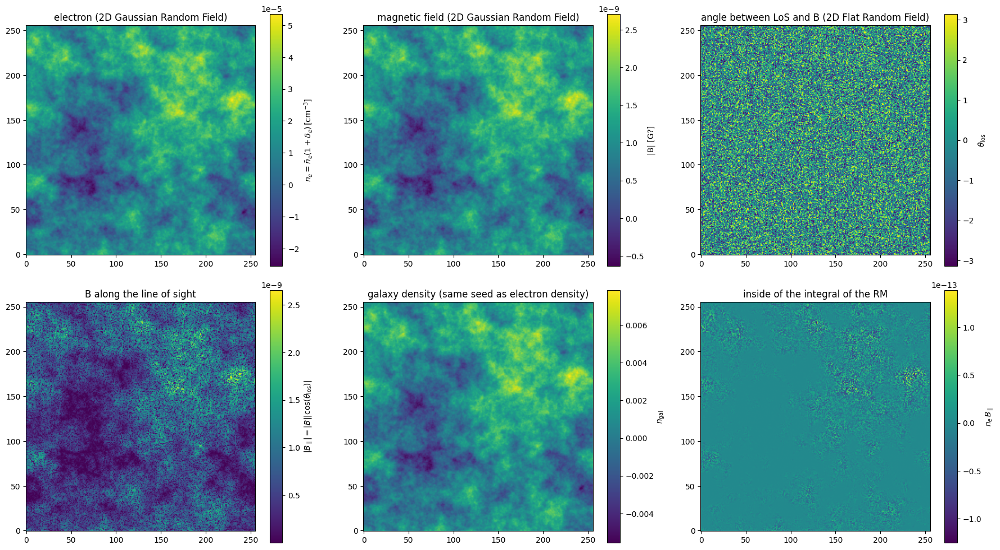

In [85]:
print("correlation between cos(theta) and B_parallel")

delta_m = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-3,
    seed=42
)
bias_em = 0.9
electron_density = mean_electron_density(z=3)*(1+delta_m*bias_em)
bias_gm = 2
galaxy_density = 1e-3*(1+delta_m*bias_gm)

delta_B = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-1,
    seed=53
)
bias_Bm = 0.5
magnetic_field = 1e-9*(1.+delta_m*bias_Bm)

los_angle = generate_flat_random_field(
    grid_size=256,
    dim=2,
    vmin=-np.pi,
    vmax=np.pi,
    smooth_sigma=None,
    seed=33
)
B_para = magnetic_field * np.cos(los_angle)
B_perp = magnetic_field * np.sin(los_angle)

#---------------- compute statistics ---------------
res0 = compute_cross_statistics(
    magnetic_field,
    np.abs(B_para),
    box_size=100.
)
res = compute_cross_statistics(
    np.abs(np.cos(los_angle)),
    np.abs(B_para),
    box_size=100.
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# ---------------------------------------------------------
# Power spectra
# ---------------------------------------------------------
axes[0].plot(res0["k"][1:], res0["P11"][1:], label=r"$P_{BB}$")
axes[0].plot(res["k"][1:], res["P11"][1:], label=r"$P_{|\cos(\theta)||\cos(\theta)|}$")
axes[0].plot(res["k"][1:], res["P22"][1:], label=r"$P_{|B_\mathrm{p}||B_\mathrm{p}|}$")
axes[0].plot(res["k"][1:], res["P12"][1:], label=r"$P_{|\cos(\theta)||B_\mathrm{p}|}$")

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel(r"$P(k)$")

axes[0].set_title("Power Spectra")

axes[0].legend()
axes[0].grid()

# ---------------------------------------------------------
# Cross-correlation coefficient
# ---------------------------------------------------------

axes[1].plot(res["k"][1:], res["r_k"][1:])

axes[1].set_xlabel(r"$k$")
axes[1].set_ylabel(r"$r(k)$")

axes[1].set_title("Cross-correlation Coefficient")

axes[1].set_ylim(-1.1, 1.1)

axes[1].grid()

# ---------------------------------------------------------
# Correlation function
# ---------------------------------------------------------

axes[2].plot(res["r"], res["xi"])

axes[2].set_xlabel(r"$r$")
axes[2].set_ylabel(r"$\xi(r)$")

axes[2].set_title("Cross Correlation Function")

axes[2].grid()

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

# =====================================================
# 1
# =====================================================

im0 = axes[0, 0].imshow(
    electron_density,
    origin='lower'
)

axes[0, 0].set_title(
    r"electron (2D Gaussian Random Field)"
)

cbar0 = plt.colorbar(
    im0,
    ax=axes[0, 0]
)

cbar0.set_label(
    r'$n_e=\bar{n}_e(1+\delta_e)\,[\mathrm{cm}^{-3}]$'
)

# =====================================================
# 2
# =====================================================

im1 = axes[0, 1].imshow(
    magnetic_field,
    origin='lower'
)

axes[0, 1].set_title(
    "magnetic field (2D Gaussian Random Field)"
)

cbar1 = plt.colorbar(
    im1,
    ax=axes[0, 1]
)

cbar1.set_label('|B| [G?]')

# =====================================================
# 3
# =====================================================

im2 = axes[0, 2].imshow(
    los_angle,
    origin='lower'
)

axes[0, 2].set_title(
    "angle between LoS and B (2D Flat Random Field)"
)

cbar2 = plt.colorbar(
    im2,
    ax=axes[0, 2]
)

cbar2.set_label(
    r'$\theta_\mathrm{los}$'
)

# =====================================================
# 4
# =====================================================

im3 = axes[1, 0].imshow(
    np.abs(B_para),
    origin='lower'
)

axes[1, 0].set_title(
    "B along the line of sight"
)

cbar3 = plt.colorbar(
    im3,
    ax=axes[1, 0]
)

cbar3.set_label(
    r'$|B_{\parallel}|=|B||\cos(\theta_\mathrm{los})|$'
)

# =====================================================
# 5
# =====================================================

im4 = axes[1, 1].imshow(
    galaxy_density,
    origin='lower'
)

axes[1, 1].set_title(
    "galaxy density (same seed as electron density)"
)

cbar4 = plt.colorbar(
    im4,
    ax=axes[1, 1]
)

cbar4.set_label(
    r'$n_\mathrm{gal}$'
)

# =====================================================
# 6
# =====================================================

im5 = axes[1, 2].imshow(
    B_para * electron_density,
    origin='lower'
)

axes[1, 2].set_title(
    "inside of the integral of the RM"
)

cbar5 = plt.colorbar(
    im5,
    ax=axes[1, 2]
)

cbar5.set_label(
    r'$n_e\,B_{\parallel}$'
)

# =====================================================
# Layout
# =====================================================

plt.tight_layout()

plt.show()

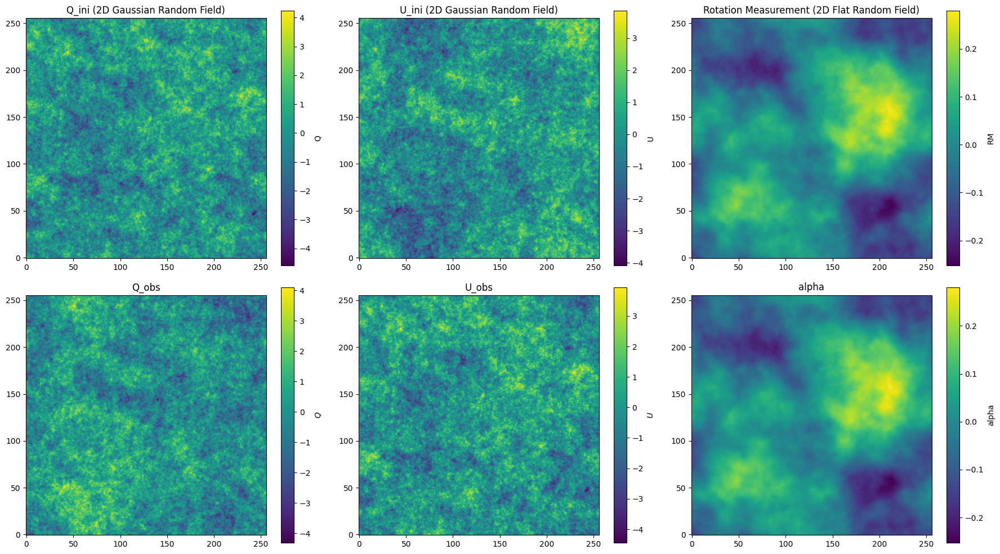

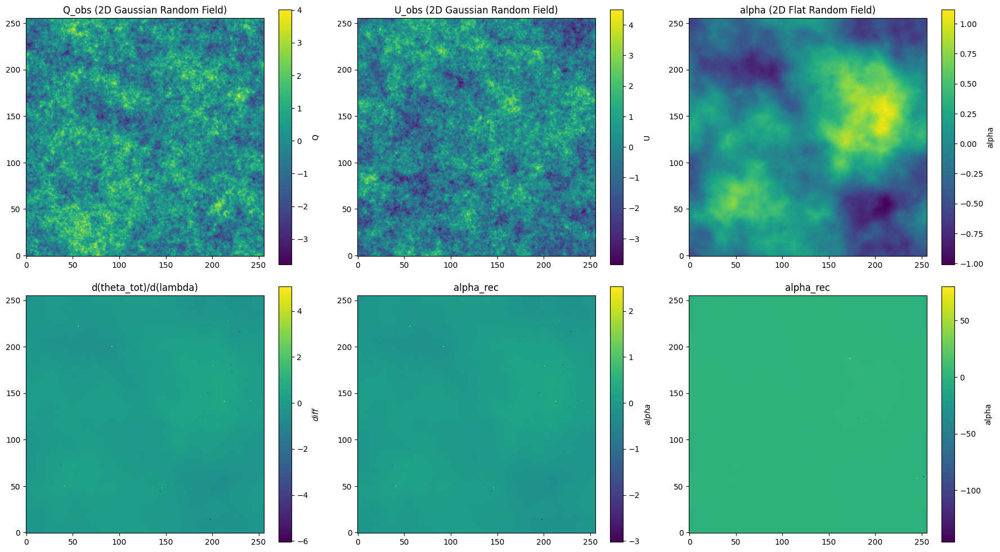

In [106]:
Q_ini = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-2,
    seed=42
)

U_ini = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-2,
    seed=20
)

RM_map = generate_gaussian_random_field(
    grid_size=256,
    dim=2,
    power_law_index=-4,
    seed=53
)
RM_map *= 0.1
#theta = np.pi/10.*7.
theta_grobal = np.ones((256,256,100))*theta
lambda_obs = np.linspace(1, 2, 100)
dlambda = lambda_obs[1] - lambda_obs[0]

Q_ini = np.repeat(Q_ini[:, :, np.newaxis], len(lambda_obs), axis=2)
U_ini = np.repeat(U_ini[:, :, np.newaxis], len(lambda_obs), axis=2)
alpha_map = np.repeat(RM_map[:, :, np.newaxis], len(lambda_obs), axis=2) * lambda_obs**2
rotation = theta_grobal + alpha_map
Q_obs = Q_ini * np.cos(2.*rotation) + U_ini * np.sin(2.*rotation)
U_obs = -Q_ini * np.sin(2.*rotation) + U_ini * np.cos(2.*rotation)

# d(theta)/d(lambda) = 1/2 / U_obs * d(Q_obs)/d(lambda)
d_arr = np.gradient(Q_obs, dlambda, axis=2)/U_obs/2.
alpha_rec = d_arr*lambda_obs/2.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

# =====================================================
# 1
# =====================================================

im0 = axes[0, 0].imshow(
    Q_ini[:,:,0],
    origin='lower'
)

axes[0, 0].set_title(
    r"Q_ini (2D Gaussian Random Field)"
)

cbar0 = plt.colorbar(
    im0,
    ax=axes[0, 0]
)

cbar0.set_label(
    r'Q'
)

# =====================================================
# 2
# =====================================================

im1 = axes[0, 1].imshow(
    U_ini[:,:,0],
    origin='lower'
)

axes[0, 1].set_title(
    "U_ini (2D Gaussian Random Field)"
)

cbar1 = plt.colorbar(
    im1,
    ax=axes[0, 1]
)

cbar1.set_label('U')

# =====================================================
# 3
# =====================================================

im2 = axes[0, 2].imshow(
    RM_map,
    origin='lower'
)

axes[0, 2].set_title(
    "Rotation Measurement (2D Flat Random Field)"
)

cbar2 = plt.colorbar(
    im2,
    ax=axes[0, 2]
)

cbar2.set_label(
    r'RM'
)

# =====================================================
# 4
# =====================================================

im3 = axes[1, 0].imshow(
    Q_obs[:,:,0],
    origin='lower'
)

axes[1, 0].set_title(
    "Q_obs"
)

cbar3 = plt.colorbar(
    im3,
    ax=axes[1, 0]
)

cbar3.set_label(
    r'$Q$'
)

# =====================================================
# 5
# =====================================================

im4 = axes[1, 1].imshow(
    U_obs[:,:,0],
    origin='lower'
)

axes[1, 1].set_title(
    "U_obs"
)

cbar4 = plt.colorbar(
    im4,
    ax=axes[1, 1]
)

cbar4.set_label(
    r'$U$'
)

# =====================================================
# 6
# =====================================================

im5 = axes[1, 2].imshow(
    alpha_map[:,:,0],
    origin='lower'
)

axes[1, 2].set_title(
    "alpha"
)

cbar5 = plt.colorbar(
    im5,
    ax=axes[1, 2]
)

cbar5.set_label(
    r'alpha'
)

# =====================================================
# Layout
# =====================================================

plt.tight_layout()

plt.show()


fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

# =====================================================
# 1
# =====================================================

im0 = axes[0, 0].imshow(
    Q_obs[:,:,-1],
    origin='lower'
)

axes[0, 0].set_title(
    r"Q_obs (2D Gaussian Random Field)"
)

cbar0 = plt.colorbar(
    im0,
    ax=axes[0, 0]
)

cbar0.set_label(
    r'Q'
)

# =====================================================
# 2
# =====================================================

im1 = axes[0, 1].imshow(
    U_obs[:,:,-1],
    origin='lower'
)

axes[0, 1].set_title(
    "U_obs (2D Gaussian Random Field)"
)

cbar1 = plt.colorbar(
    im1,
    ax=axes[0, 1]
)

cbar1.set_label('U')

# =====================================================
# 3
# =====================================================

im2 = axes[0, 2].imshow(
    alpha_map[:,:,-1],
    origin='lower'
)

axes[0, 2].set_title(
    "alpha (2D Flat Random Field)"
)

cbar2 = plt.colorbar(
    im2,
    ax=axes[0, 2]
)

cbar2.set_label(
    r'alpha'
)

# =====================================================
# 4
# =====================================================

im3 = axes[1, 0].imshow(
    d_arr[:,:,0],
    origin='lower'
)

axes[1, 0].set_title(
    "d(theta_tot)/d(lambda)"
)

cbar3 = plt.colorbar(
    im3,
    ax=axes[1, 0]
)

cbar3.set_label(
    r'$diff$'
)

# =====================================================
# 5
# =====================================================

im4 = axes[1, 1].imshow(
    alpha_rec[:,:,0],
    origin='lower'
)

axes[1, 1].set_title(
    "alpha_rec"
)

cbar4 = plt.colorbar(
    im4,
    ax=axes[1, 1]
)

cbar4.set_label(
    r'$alpha$'
)

# =====================================================
# 6
# =====================================================

im5 = axes[1, 2].imshow(
    alpha_rec[:,:,-1],
    origin='lower'
)

axes[1, 2].set_title(
    "alpha_rec"
)

cbar5 = plt.colorbar(
    im5,
    ax=axes[1, 2]
)

cbar5.set_label(
    r'alpha'
)

# =====================================================
# Layout
# =====================================================

plt.tight_layout()

plt.show()

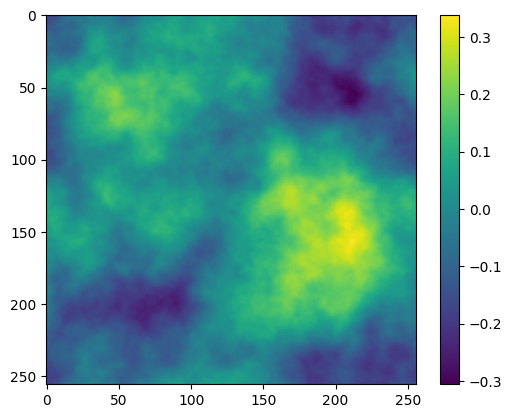

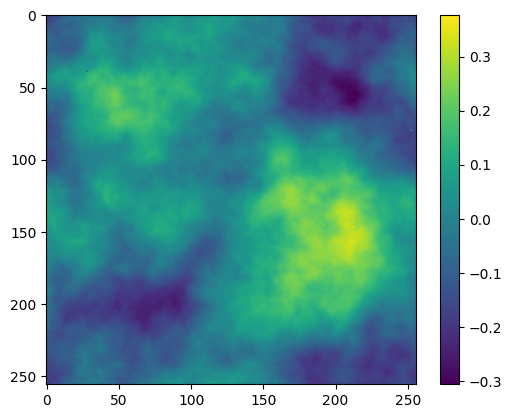

In [111]:
"""
for i in range(10):
    plt.figure(figsize=(3,3))
    #plt.imshow(alpha_map[:,:,i*9])
    plt.imshow(Q_obs[:,:,i*9])
    plt.colorbar()
    plt.show()
"""

plt.imshow(alpha_map[:,:,10])
plt.colorbar()
plt.show()

plt.imshow(alpha_rec[:,:,10])
#plt.clim(np.min(alpha_map[:,:,1]),np.max(alpha_map[:,:,1]))
plt.colorbar()
plt.show()

In [72]:
bb = np.std(np.abs(B_para))/np.mean(np.abs(B_para))
bbb = np.std((np.abs(np.cos(los_angle))))/np.mean(np.abs(np.cos(los_angle)))
print(bb)
print(bbb)

0.7230673536730621
0.4838296424931306


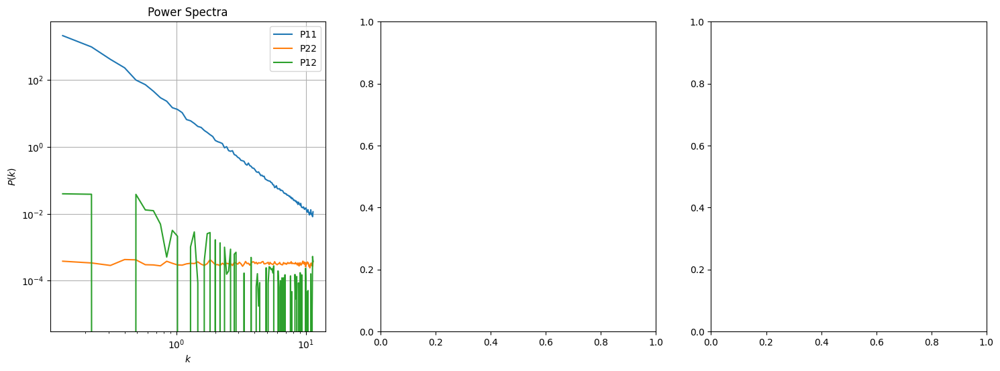

In [61]:
#---------------- compute statistics ---------------
res = compute_cross_statistics(
    galaxy_density,
    los_angle/np.pi+1,
    box_size=100.
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# ---------------------------------------------------------
# Power spectra
# ---------------------------------------------------------

axes[0].plot(res["k"][1:], res["P11"][1:], label="P11")
axes[0].plot(res["k"][1:], res["P22"][1:], label="P22")
axes[0].plot(res["k"][1:], res["P12"][1:], label="P12")

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel(r"$P(k)$")

axes[0].set_title("Power Spectra")

axes[0].legend()
axes[0].grid()